=== STATISTICHE GENERALI (tutti i pacchetti) ===


,count,percent
pred_class,,
p0,1037.0,12.60
p1,7163.0,87.07
p2,27.0,0.33
TOTAL,8227.0,100.00



=== STATISTICHE SOLO flow_id con 192.168.* ===
Pacchetti con flow_id che matcha '\b192\.168\.': 226 su 8227 (2.75%)


,count,percent
pred_class,,
p0,96.0,42.48
p1,103.0,45.58
p2,27.0,11.95
TOTAL,226.0,100.00



=== RIASSUNTO (solo classi) ===


ALL         ONLY_192.168        
             count percent        count percent
pred_class                                     
p0          1037.0   12.60         96.0   42.48
p1          7163.0   87.07        103.0   45.58
p2            27.0    0.33         27.0   11.95

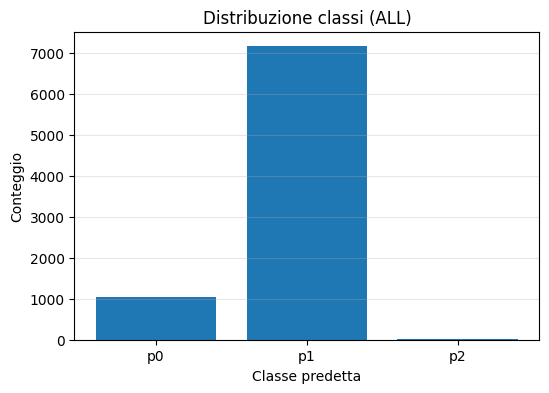

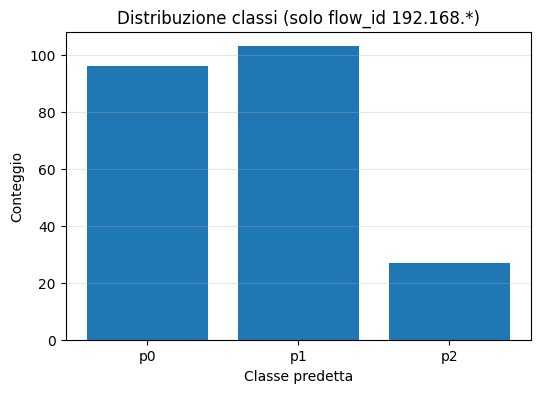

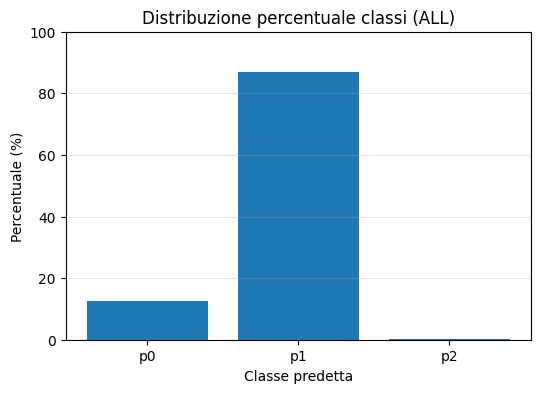

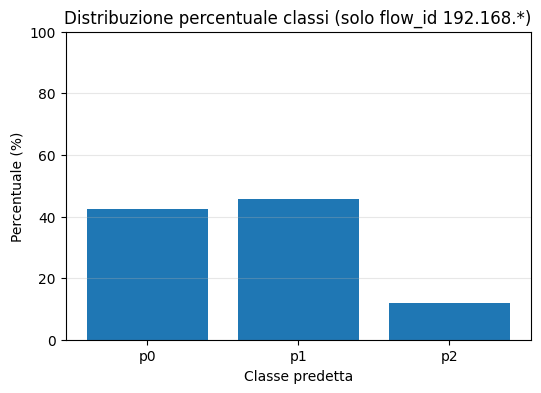

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Config
# =========================
CSV_PATHS = [
    "results/predictions_log_experiment_WINDOW50_DOS3.csv"
]

FLOW_IP_PREFIX_REGEX = r"\b192\.168\."  # match "192.168." dentro flow_id
CLASS_ORDER = ["p0", "p1", "p2"]

# =========================
# Helpers
# =========================
def _expand_paths(paths):
    out = []
    for p in paths:
        p = Path(p)
        if "*" in str(p):
            out.extend([Path(x) for x in sorted(p.parent.glob(p.name))])
        elif p.is_dir():
            out.extend(sorted(p.glob("*.csv")))
        else:
            out.append(p)
    seen = set()
    unique = []
    for f in out:
        if f not in seen:
            unique.append(f)
            seen.add(f)
    return unique

def load_csvs(csv_paths):
    files = _expand_paths(csv_paths)
    if not files:
        raise FileNotFoundError("Nessun CSV trovato. Controlla CSV_PATHS.")
    dfs = []
    for f in files:
        df = pd.read_csv(f)
        df["__source_file"] = str(f)
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

def classify_rows(df, p_cols=("p0", "p1", "p2"), label_names=("p0", "p1", "p2")):
    missing = [c for c in ["flow_id", *p_cols] if c not in df.columns]
    if missing:
        raise ValueError(f"Mancano colonne nel CSV: {missing}")

    for c in p_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    probs = df.loc[:, list(p_cols)].to_numpy(dtype=float)

    # Se una riga ha tutte NaN, nanargmax esplode: gestiamolo
    all_nan = np.all(np.isnan(probs), axis=1)
    probs_safe = probs.copy()
    probs_safe[all_nan] = -np.inf

    argmax = np.argmax(probs_safe, axis=1)
    df["pred_class"] = [label_names[i] for i in argmax]
    df.loc[all_nan, "pred_class"] = np.nan

    df["pred_prob"] = np.nanmax(probs, axis=1)

    return df

def make_stats(df):
    counts = df["pred_class"].value_counts(dropna=False).reindex(CLASS_ORDER, fill_value=0)
    perc = (counts / max(len(df), 1) * 100).round(2)
    stats = pd.DataFrame({"count": counts, "percent": perc})
    stats.loc["TOTAL"] = [len(df), 100.0 if len(df) > 0 else 0.0]
    return stats

def flowid_has_192(df, regex=FLOW_IP_PREFIX_REGEX):
    s = df["flow_id"].astype(str)
    return s.str.contains(regex, regex=True, na=False)

# =========================
# Plot helpers (matplotlib only)
# =========================
def plot_class_distribution(stats, title):
    """stats: output di make_stats(df)"""
    cls = [c for c in CLASS_ORDER if c in stats.index]
    counts = stats.loc[cls, "count"].astype(int).values

    plt.figure(figsize=(6, 4))
    plt.bar(cls, counts)
    plt.title(title)
    plt.xlabel("Classe predetta")
    plt.ylabel("Conteggio")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

def plot_class_distribution_percent(stats, title):
    cls = [c for c in CLASS_ORDER if c in stats.index]
    perc = stats.loc[cls, "percent"].astype(float).values

    plt.figure(figsize=(6, 4))
    plt.bar(cls, perc)
    plt.title(title)
    plt.xlabel("Classe predetta")
    plt.ylabel("Percentuale (%)")
    plt.ylim(0, max(100, float(np.nanmax(perc)) + 5))
    plt.grid(axis="y", alpha=0.3)
    plt.show()

def plot_time_series_counts(df, ts_col="ts", freq="1Min", title="Conteggi per classe nel tempo"):
    """
    Aggrega su intervalli regolari (freq) e mostra una linea per classe.
    Nota: richiede colonna ts interpretabile come unix epoch (secondi) o datetime.
    """
    if ts_col not in df.columns:
        print(f"[plot_time_series_counts] Colonna '{ts_col}' non presente: salto plot.")
        return

    ts = df[ts_col]

    # Prova a interpretare come epoch seconds (float/int)
    if np.issubdtype(ts.dtype, np.number):
        t = pd.to_datetime(ts, unit="s", errors="coerce")
    else:
        t = pd.to_datetime(ts, errors="coerce")

    tmp = df.copy()
    tmp["_t"] = t
    tmp = tmp.dropna(subset=["_t", "pred_class"])

    if tmp.empty:
        print("[plot_time_series_counts] Nessun dato valido per il plot temporale.")
        return

    tmp = tmp.set_index("_t")
    counts = (
        tmp.groupby([pd.Grouper(freq=freq), "pred_class"])
           .size()
           .unstack(fill_value=0)
           .reindex(columns=CLASS_ORDER, fill_value=0)
    )

    plt.figure(figsize=(10, 4))
    for c in CLASS_ORDER:
        if c in counts.columns:
            plt.plot(counts.index, counts[c].values, label=c)
    plt.title(title + f" (freq={freq})")
    plt.xlabel("Tempo")
    plt.ylabel("Conteggio")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# =========================
# Main
# =========================
df = load_csvs(CSV_PATHS)

df = df.dropna(subset=["flow_id"]).copy()
df = classify_rows(df, p_cols=("p0", "p1", "p2"), label_names=("p0", "p1", "p2"))

mask_192 = flowid_has_192(df, FLOW_IP_PREFIX_REGEX)
df_192 = df.loc[mask_192].copy()

# Statistiche
stats_all = make_stats(df)
stats_192 = make_stats(df_192)

print("=== STATISTICHE GENERALI (tutti i pacchetti) ===")
display(stats_all)

print("\n=== STATISTICHE SOLO flow_id con 192.168.* ===")
print(f"Pacchetti con flow_id che matcha '{FLOW_IP_PREFIX_REGEX}': {mask_192.sum()} su {len(df)} "
      f"({(mask_192.mean()*100 if len(df)>0 else 0):.2f}%)")
display(stats_192)

summary = pd.concat(
    {"ALL": stats_all.drop(index="TOTAL", errors="ignore"),
     "ONLY_192.168": stats_192.drop(index="TOTAL", errors="ignore")},
    axis=1
)
print("\n=== RIASSUNTO (solo classi) ===")
display(summary)

# =========================
# Plotting
# =========================
# 1) Distribuzione conteggi (ALL vs 192.168)
plot_class_distribution(stats_all, "Distribuzione classi (ALL)")
plot_class_distribution(stats_192, "Distribuzione classi (solo flow_id 192.168.*)")

# 2) Distribuzione percentuale (ALL vs 192.168)
plot_class_distribution_percent(stats_all, "Distribuzione percentuale classi (ALL)")
plot_class_distribution_percent(stats_192, "Distribuzione percentuale classi (solo flow_id 192.168.*)")



Accuracy (regole aggiornate): 0.9967  (99.67%)
Totale campioni: 8227 | Corretti: 8200 | Errati: 27


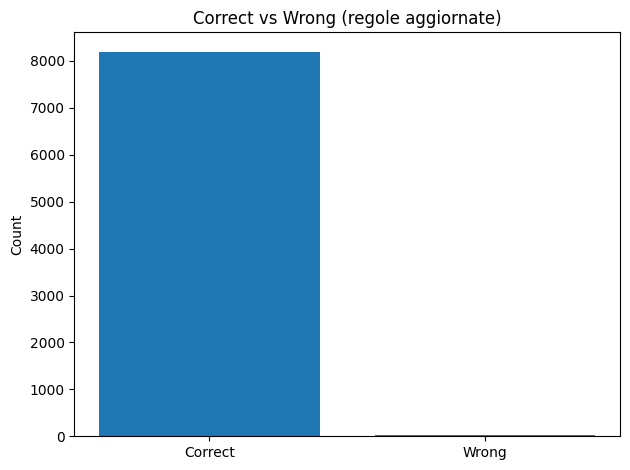

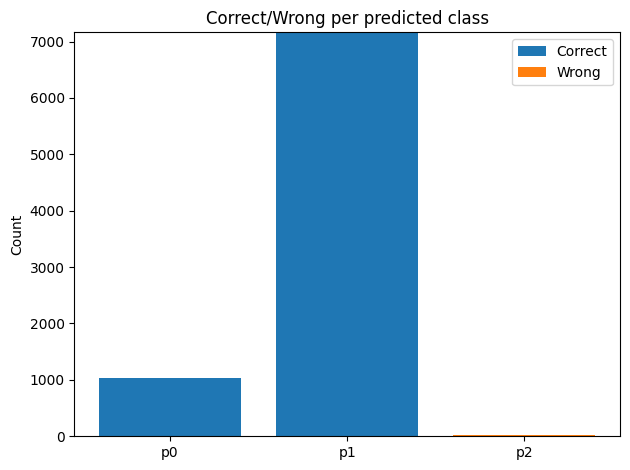

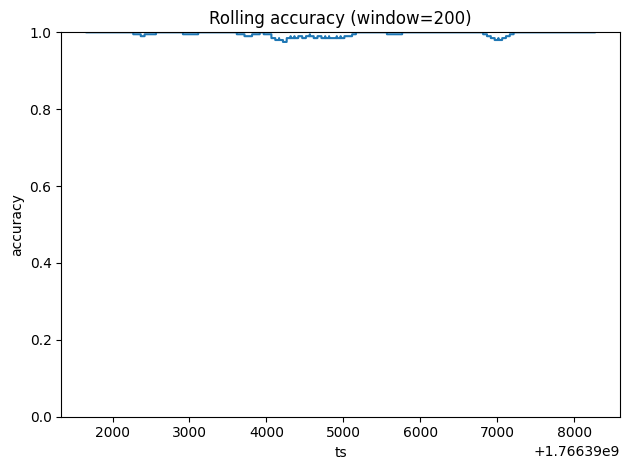

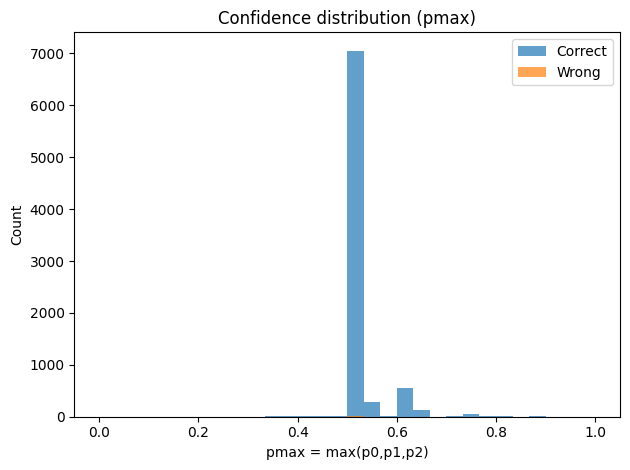

Subset 192.168.*: N=226 | acc=0.8805
Subset 10.0.0.2*: N=7070 | acc=1.0000
Resto: N=931 | acc=1.0000


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = "results/predictions_log_experiment_WINDOW50_DOS3.csv"

df = pd.read_csv(CSV_PATH)

# Predicted class = argmax(p0,p1,p2)
probs = df[["p0", "p1", "p2"]].to_numpy()
pred_idx = np.argmax(probs, axis=1)
idx2label = np.array(["p0", "p1", "p2"])
df["pred"] = idx2label[pred_idx]
df["pmax"] = probs.max(axis=1)

# Parse IPs from flow_id
def extract_ips(flow_id: str):
    parts = str(flow_id).split("|")
    if len(parts) < 2:
        return (None, None)
    ip1 = parts[0].split(":")[0]
    ip2 = parts[1].split(":")[0]
    return ip1, ip2

ips = df["flow_id"].apply(extract_ips)
df["ip_a"] = ips.apply(lambda t: t[0])
df["ip_b"] = ips.apply(lambda t: t[1])

# Flags
df["in_192"] = df["ip_a"].fillna("").str.startswith("192.168.") | df["ip_b"].fillna("").str.startswith("192.168.")
df["in_10_0_0_2"] = df["ip_a"].fillna("").str.startswith("10.0.0.2") | df["ip_b"].fillna("").str.startswith("10.0.0.2")

# === Correctness rules (UPDATED) ===
# p2 is always wrong (for everyone)
df["correct"] = df["pred"].ne("p2")

# (No extra constraint for 10.0.0.2* anymore, since p0/p1 correct and only p2 wrong.)
# (For 192.168.* it's also p0/p1 correct, p2 wrong -> already handled)

# Accuracy
acc = df["correct"].mean()
print(f"Accuracy (regole aggiornate): {acc:.4f}  ({acc*100:.2f}%)")
print(f"Totale campioni: {len(df)} | Corretti: {df['correct'].sum()} | Errati: {(~df['correct']).sum()}")

# =========================
#           PLOTS
# =========================

# 1) Correct vs Wrong
counts = df["correct"].value_counts().reindex([True, False]).fillna(0).astype(int)
plt.figure()
plt.bar(["Correct", "Wrong"], counts.values)
plt.title("Correct vs Wrong (regole aggiornate)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 2) Breakdown per classe predetta
classes = ["p0", "p1", "p2"]
corr_by_class = df[df["correct"]].groupby("pred").size().reindex(classes).fillna(0).astype(int)
wrong_by_class = df[~df["correct"]].groupby("pred").size().reindex(classes).fillna(0).astype(int)

plt.figure()
x = np.arange(len(classes))
plt.bar(x, corr_by_class.values, label="Correct")
plt.bar(x, wrong_by_class.values, bottom=corr_by_class.values, label="Wrong")
plt.xticks(x, classes)
plt.title("Correct/Wrong per predicted class")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# 3) Rolling accuracy nel tempo (se ts esiste ed è numerico)
if "ts" in df.columns and np.issubdtype(df["ts"].dtype, np.number):
    df_sorted = df.sort_values("ts").copy()
    window = 200
    roll_acc = df_sorted["correct"].rolling(window=window, min_periods=max(10, window//10)).mean()

    plt.figure()
    plt.plot(df_sorted["ts"].to_numpy(), roll_acc.to_numpy())
    plt.title(f"Rolling accuracy (window={window})")
    plt.xlabel("ts")
    plt.ylabel("accuracy")
    plt.ylim(0, 1.0)
    plt.tight_layout()
    plt.show()

# 4) Confidenza (pmax) per corretti vs errati
bins = np.linspace(0, 1, 31)
plt.figure()
plt.hist(df.loc[df["correct"], "pmax"].dropna(), bins=bins, alpha=0.7, label="Correct")
plt.hist(df.loc[~df["correct"], "pmax"].dropna(), bins=bins, alpha=0.7, label="Wrong")
plt.title("Confidence distribution (pmax)")
plt.xlabel("pmax = max(p0,p1,p2)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# 5) Accuracy per subset (solo reporting)
def subset_acc(mask, name):
    n = int(mask.sum())
    if n == 0:
        print(f"{name}: N=0")
    else:
        print(f"{name}: N={n} | acc={df.loc[mask,'correct'].mean():.4f}")

subset_acc(df["in_192"], "Subset 192.168.*")
subset_acc(df["in_10_0_0_2"], "Subset 10.0.0.2*")
subset_acc(~(df["in_192"] | df["in_10_0_0_2"]), "Resto")


In [14]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

CSV_PATH = "results/predictions_log_experiment_WINDOW60_DOS3.csv"

df = pd.read_csv(CSV_PATH)

# ===============================
# Predicted class = argmax
# ===============================
probs = df[["p0", "p1", "p2"]].to_numpy()
pred_idx = np.argmax(probs, axis=1)
labels = np.array(["p0", "p1", "p2"])
df["pred"] = labels[pred_idx]

# ===============================
# Extract IPs
# ===============================
def extract_ips(flow_id):
    parts = str(flow_id).split("|")
    if len(parts) < 2:
        return None, None
    return parts[0].split(":")[0], parts[1].split(":")[0]

ips = df["flow_id"].apply(extract_ips)
df["ip_a"] = ips.apply(lambda x: x[0])
df["ip_b"] = ips.apply(lambda x: x[1])

df["in_192"] = (
    df["ip_a"].fillna("").str.startswith("192.168.") |
    df["ip_b"].fillna("").str.startswith("192.168.")
)

df["in_10_0_0_2"] = (
    df["ip_a"].fillna("").str.startswith("10.0.0.2") |
    df["ip_b"].fillna("").str.startswith("10.0.0.2")
)

# ===============================
# Correctness rules (FINAL)
# ===============================
df["correct"] = False

# 192.168.*  → p0 or p1 ok
mask_192 = df["in_192"]
df.loc[mask_192, "correct"] = df.loc[mask_192, "pred"].isin(["p0", "p1"])

# 10.0.0.2* → p0 or p1 ok
mask_10 = df["in_10_0_0_2"]
df.loc[mask_10, "correct"] = df.loc[mask_10, "pred"].isin(["p0", "p1"])

# resto → SOLO p0 ok
mask_rest = ~(mask_192 | mask_10)
df.loc[mask_rest, "correct"] = df.loc[mask_rest, "pred"].eq("p0")

# ===============================
# Binary labels for metrics
# ===============================
y_true = np.ones(len(df), dtype=int)          # tutti i flow dovrebbero essere corretti
y_pred = df["correct"].astype(int).to_numpy() # decisione del modello

# ===============================
# Metrics
# ===============================
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("=== RULE-BASED PERFORMANCE METRICS ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nBreakdown:")
print(f"Totale campioni : {len(df)}")
print(f"Corretti        : {df['correct'].sum()}")
print(f"Errati          : {(~df['correct']).sum()}")


=== RULE-BASED PERFORMANCE METRICS ===
Accuracy : 0.9958
Precision: 1.0000
Recall   : 0.9958
F1-score : 0.9979

Breakdown:
Totale campioni : 947
Corretti        : 943
Errati          : 4


In [23]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

CSV_PATH = "results/predictions_log_experiment_WINDOW50_INTEGRITY1.csv"  # cambia se serve
df = pd.read_csv(CSV_PATH)

def extract_ips(flow_id: str):
    parts = str(flow_id).split("|")
    if len(parts) < 2:
        return (None, None)
    ip1 = parts[0].split(":")[0]
    ip2 = parts[1].split(":")[0]
    return ip1, ip2

ips = df["flow_id"].apply(extract_ips)
df["ip_a"] = ips.apply(lambda t: t[0])
df["ip_b"] = ips.apply(lambda t: t[1])

# True label by rule:
is_192 = df["ip_a"].fillna("").str.startswith("192.168") | df["ip_b"].fillna("").str.startswith("192.168")
df["y_true"] = np.where(is_192, "p2", "p0")

# Pred label by argmax:
probs = df[["p0", "p1", "p2"]].to_numpy()
df["y_pred"] = np.array(["p0", "p1", "p2"])[np.argmax(probs, axis=1)]

# Binary metrics (positive = p2)
y_true = (df["y_true"] == "p2").astype(int)
y_pred = (df["y_pred"] == "p2").astype(int)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")


Accuracy  : 0.8732
Precision : 1.0000
Recall    : 0.4091
F1-score  : 0.5806
